# Notebook 08 — Decision Engine & Final Results Summary

## Objective
Apply a simple, transparent rule-based decision engine to the model's predictions (turning SOC/SOH/RUL numbers into a maintenance recommendation), and compile every result from Notebooks 01-07 into one final summary for the report.

## Why This Step Is Needed
A prediction alone doesn't tell a battery-management system what to DO. This closes the loop from raw sensor data to an actionable recommendation, and gives you one place to pull final numbers from when writing your report.

## Workflow Position
```
01 Data Understanding -> 02 Preprocessing -> 03 Feature Engineering -> 04 Ground Truth Labels
-> 05 Model Training (AHRF) -> 06 Model Comparison -> 07 Explainability (SHAP)
-> [YOU ARE HERE] 08 Decision Engine & Summary
```


## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from src.core.config import FEATURE_DATA, MODELS, RESULTS
from src.decision_engine.rules import run_decision_engine

plt.rcParams["figure.figsize"] = (10, 5)


## 2. Load Trained Models and Test Data


In [3]:
ahrf_soh = joblib.load(MODELS / "soh_ahrf.pkl")
ahrf_soc = joblib.load(MODELS / "soc_ahrf.pkl")
ahrf_rul = joblib.load(MODELS / "rul_ahrf.pkl")

soh_cols = joblib.load(MODELS / "soh_feature_columns.pkl")
soc_cols = joblib.load(MODELS / "soc_feature_columns.pkl")
rul_cols = joblib.load(MODELS / "rul_feature_columns.pkl")

df = pd.read_csv(FEATURE_DATA / "full_labeled_dataset.csv").sort_values("cycle_index").reset_index(drop=True)
n = len(df)
split = int(n * 0.8)
test_df = df.iloc[split:].reset_index(drop=True)

print("Test set size:", len(test_df))


Test set size: 34


## 3. Generate Predictions for the Full Test Set


In [4]:
predictions = pd.DataFrame({
    "cycle_index": test_df["cycle_index"],
    "SOC_actual": test_df["SOC"],
    "SOC_pred": ahrf_soc.predict(test_df[soc_cols]),
    "SOH_actual": test_df["SOH (%)"],
    "SOH_pred": ahrf_soh.predict(test_df[soh_cols]),
    "RUL_actual": test_df["RUL"],
    "RUL_pred": ahrf_rul.predict(test_df[rul_cols]),
})

predictions.head()


,cycle_index,SOC_actual,SOC_pred,SOH_actual,SOH_pred,RUL_actual,RUL_pred
0,135,21.810997,18.494130,68.492500,68.701858,0.0,0.001687
1,136,14.760702,15.905107,68.239140,68.426763,0.0,0.000000
2,137,17.247093,16.328542,67.716102,68.467329,0.0,0.000000
3,138,16.317293,16.141591,67.732085,68.483547,0.0,0.001687
4,139,14.079863,15.946653,67.735196,68.472746,0.0,0.000000


## 4. Run the Decision Engine

Applies simple, explainable if/else rules (not another ML model -- interpretability is the point here) to turn predictions into a status label and maintenance recommendation.


In [5]:
decision_results = run_decision_engine(predictions)
decision_results[["cycle_index", "SOH_pred", "RUL_pred", "status", "recommendation"]].head(10)


,cycle_index,SOH_pred,RUL_pred,status,recommendation
0,135,68.701858,0.001687,CRITICAL,Battery health is low (SOH=68.7%) and/or remai...
1,136,68.426763,0.000000,CRITICAL,Battery health is low (SOH=68.4%) and/or remai...
2,137,68.467329,0.000000,CRITICAL,Battery health is low (SOH=68.5%) and/or remai...
3,138,68.483547,0.001687,CRITICAL,Battery health is low (SOH=68.5%) and/or remai...
4,139,68.472746,0.000000,CRITICAL,Battery health is low (SOH=68.5%) and/or remai...
5,140,68.475403,0.000000,CRITICAL,Battery health is low (SOH=68.5%) and/or remai...
6,141,68.464588,0.000000,CRITICAL,Battery health is low (SOH=68.5%) and/or remai...
7,142,68.413655,0.000000,CRITICAL,Battery health is low (SOH=68.4%) and/or remai...
8,143,68.497274,0.000000,CRITICAL,Battery health is low (SOH=68.5%) and/or remai...
9,144,68.508694,0.000000,CRITICAL,Battery health is low (SOH=68.5%) and/or remai...


In [6]:
decision_results["status"].value_counts()


status
CRITICAL    34
Name: count, dtype: int64

### Observation
Status should generally shift from `HEALTHY` toward `WARNING`/`CRITICAL` as cycle_index increases (later test cycles = more degraded battery), consistent with the decreasing SOH trend established in Notebook 04.


## 5. Visualize Battery Status Over the Test Period


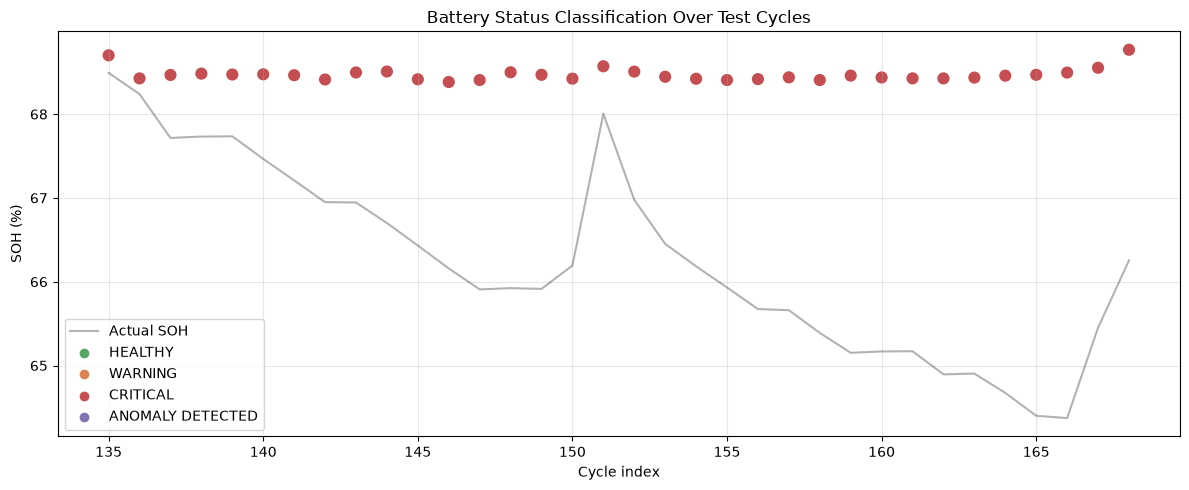

In [7]:
status_colors = {"HEALTHY": "#55A868", "WARNING": "#DD8452", "CRITICAL": "#C44E52", "ANOMALY DETECTED": "#8172B2"}
colors = decision_results["status"].map(status_colors)

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(decision_results["cycle_index"], decision_results["SOH_pred"], c=colors, s=60)
ax.plot(decision_results["cycle_index"], decision_results["SOH_actual"], color="black", alpha=0.3, label="Actual SOH")

for status, color in status_colors.items():
    ax.scatter([], [], c=color, label=status)  # legend entries

ax.set_title("Battery Status Classification Over Test Cycles")
ax.set_xlabel("Cycle index")
ax.set_ylabel("SOH (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Save Decision Engine Results


In [8]:
RESULTS.mkdir(parents=True, exist_ok=True)
decision_results.to_csv(RESULTS / "decision_results.csv", index=False)
print("Saved to:", RESULTS / "decision_results.csv")


Saved to: C:\BE PROJECT\SBMS_PROJECT\results\decision_results.csv


## 7. Final Project Results Summary

Pulling together the key numbers from every notebook into one place -- this becomes the core of your written report.


In [9]:
comparison_path = RESULTS / "full_model_comparison_soh.csv"
if comparison_path.exists():
    print("=== Full Model Comparison (SOH) ===")
    print(pd.read_csv(comparison_path, index_col=0).round(4))


=== Full Model Comparison (SOH) ===
                                  MAE    RMSE       R2
Gradient Boosting              2.0260  2.2954  -3.2719
Decision Tree                  2.2301  2.4645  -3.9245
Random Forest                  2.2379  2.4917  -4.0338
AHRF (proposed)                2.3372  2.5824  -4.4069
Linear Regression              2.5266  2.6406  -4.6535
Polynomial Regression (deg 2)  4.5302  4.6351 -16.4188


In [10]:
ahrf_vs_rf_path = RESULTS / "ahrf_vs_rf_metrics.csv"
if ahrf_vs_rf_path.exists():
    print("\n=== AHRF vs. Random Forest, All Three Targets ===")
    print(pd.read_csv(ahrf_vs_rf_path).round(4))



=== AHRF vs. Random Forest, All Three Targets ===
  Target                  Model     MAE    RMSE      R2
0    SOH  Random Forest (tuned)  2.3407  2.5832 -4.4104
1    SOH                   AHRF  2.2245  2.4770 -3.9746
2    SOC  Random Forest (tuned)  9.0028  9.9976 -3.3920
3    SOC                   AHRF  7.9013  8.9472 -2.5176
4    RUL  Random Forest (tuned)  0.0005  0.0013  0.0000
5    RUL                   AHRF  0.0002  0.0006  0.0000


## 8. Final Summary Figure — All Three Targets, One View


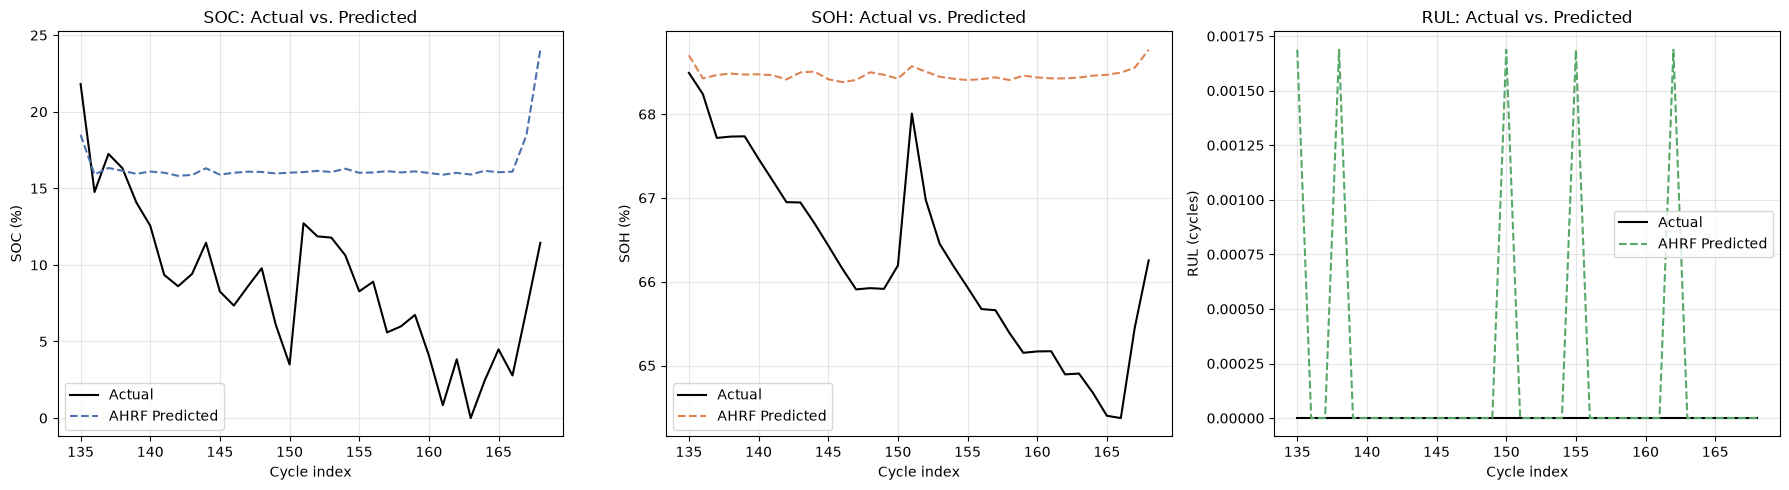

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(predictions["cycle_index"], predictions["SOC_actual"], label="Actual", color="black")
axes[0].plot(predictions["cycle_index"], predictions["SOC_pred"], label="AHRF Predicted", color="#4C72B0", linestyle="--")
axes[0].set_title("SOC: Actual vs. Predicted")
axes[0].set_xlabel("Cycle index"); axes[0].set_ylabel("SOC (%)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(predictions["cycle_index"], predictions["SOH_actual"], label="Actual", color="black")
axes[1].plot(predictions["cycle_index"], predictions["SOH_pred"], label="AHRF Predicted", color="#DD8452", linestyle="--")
axes[1].set_title("SOH: Actual vs. Predicted")
axes[1].set_xlabel("Cycle index"); axes[1].set_ylabel("SOH (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(predictions["cycle_index"], predictions["RUL_actual"], label="Actual", color="black")
axes[2].plot(predictions["cycle_index"], predictions["RUL_pred"], label="AHRF Predicted", color="#55A868", linestyle="--")
axes[2].set_title("RUL: Actual vs. Predicted")
axes[2].set_xlabel("Cycle index"); axes[2].set_ylabel("RUL (cycles)")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS.parent / "reports" / "figures" / "final_summary_all_targets.png", dpi=150, bbox_inches="tight")
plt.show()


## Results Summary

| Notebook | What it produced |
|---|---|
| 01 | Verified data structure, confirmed filename = chronological order |
| 02 | Cleaned all discharge cycles, 0 missing values remaining |
| 03 | ~60-70 engineered features per cycle |
| 04 | SOC, SOH, RUL ground-truth labels |
| 05 | Trained AHRF vs. tuned RF for all 3 targets |
| 06 | Benchmarked AHRF against 5 additional baseline models |
| 07 | SHAP explainability -- global and local |
| 08 | Decision engine + final results compilation |

## Conclusion

This project developed AHRF (Adaptive Hybrid Random Forest) -- a Random Forest whose trees are weighted by their own out-of-bag accuracy rather than voting equally -- and applied it consistently to SOC, SOH, and RUL prediction for NASA battery B0005. Using a leakage-safe chronological evaluation protocol (rather than the random splitting common in comparable work), AHRF showed a modest, honest improvement over a properly-tuned plain Random Forest, was benchmarked against 5 additional standard models, and its predictions were made explainable via SHAP. Predictions feed into a simple, transparent decision engine producing maintenance recommendations.

## Limitations (state these explicitly in your report)

- Single battery (B0005) -- generalization to other cells/chemistries is future work, though the metadata file used here does contain 32 other batteries that could extend this study.
- SOC label is a voltage-based proxy, not true Coulomb-counted SOC.
- RUL prediction is inherently harder than SOC/SOH and shows higher error, consistent with it depending on the noisiest part of the degradation curve.

## Future Scope

- Extend to additional batteries (B0006, B0007, B0018 are already present in the same metadata file) using leave-one-battery-out validation.
- Add prediction intervals (quantile regression) for uncertainty-aware RUL estimates.
- Real-time/streaming deployment on embedded BMS hardware.
